In [1]:
import os
import random
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt

from src.ArtificialTrainDataGenerator import ArtificialTrainDataGenerator
from src.FeatureEnhancer import FeatureEnhancer
from src.Elements import Elements

N_SAMPLES = 250000 
SAMPLE_PER_ELEMENT = 3
SIGMA_RANGE = (0.2, 0.8)
MU_LOCAL_ERR = 0.05
MU_GLOBAL_ERR = 0.1
OUTPUT_DIR = "data/training_data/artificial"

X, y = ArtificialTrainDataGenerator.generate_dataset(
    N_SAMPLES,
    mu_local_err=MU_LOCAL_ERR,
    mu_global_err=MU_GLOBAL_ERR,
    sigma_range=SIGMA_RANGE,
    use_cache=False
)
print(y[0].tolist())


100%|██████████| 50/50 [00:00<00:00, 483214.75it/s]


[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 63.221787885402115, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 181.85966552679912, 162.12221935491186]


[  0.           0.           0.           0.           0.
   0.          63.22178789   0.           0.           0.
   0.           0.           0.           0.           0.
 181.85966553 162.12221935]


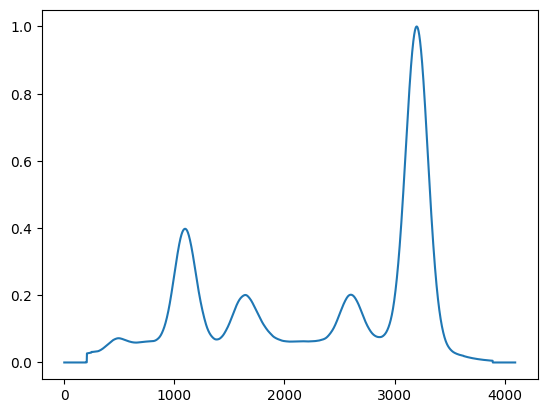

In [2]:
plt.plot(X[0])
print(y[0])

In [3]:
X = FeatureEnhancer.process_spectra(np.array(X))

100%|██████████| 51/51 [00:00<00:00, 468073.31it/s]


/tmp/ipykernel_1434581/3799171883.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


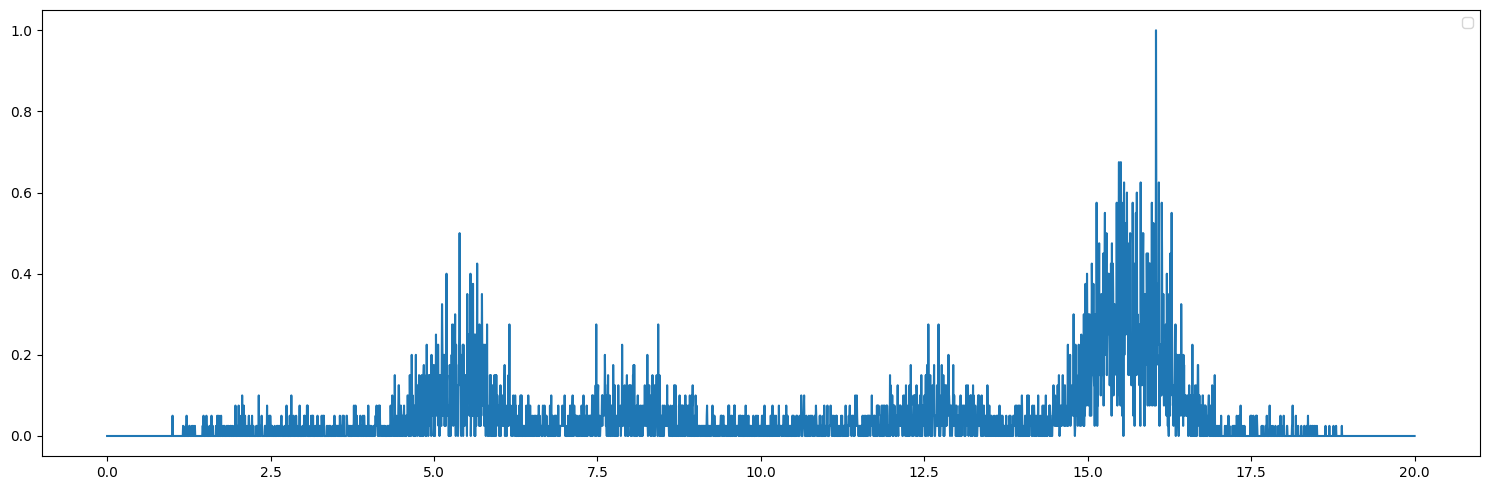

In [4]:
plt.figure(figsize=(15, 5))
label = ", ".join([
    f"{Elements.NUM2SYMBOL[j] if j < len(Elements.NUM2SYMBOL) else 'wood'}:{round(el, 2)}"
    for j, el in enumerate(y[0]) if el > 0
])
plt.plot(np.linspace(0, 20, 4096), X[0])
plt.legend()
plt.tight_layout()
plt.show()


In [5]:
def save_data(X, y, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    np.save(os.path.join(output_dir, f"X_regression_{timestamp}.npy"), X)
    np.save(os.path.join(output_dir, f"y_regression_{timestamp}.npy"), y)
    print(f"Data saved in '{output_dir}' with timestamp {timestamp}")

save_data(X, y, OUTPUT_DIR)

Data saved in 'data/training_data/artificial' with timestamp 20250606_190222
